In [ ]:
import numpy as np
import mne
from pathlib import Path
import pandas as pd
from scipy.stats import zscore


In [ ]:

CANE_DIR = Path("../CANE/")
MDD_DIR = Path("../MDD/")

In [ ]:
raw = mne.io.read_raw_edf(MDD_DIR / 'MDD S1 EC.edf', preload=True)
print(raw.info)
raw

In [ ]:
raw.plot()

## Filtering MDD dataset

In [ ]:
# https://en.wikipedia.org/wiki/Butterworth_filter
# ICA is sensitive to low-frequency drifts and therefore requires the data to be high-pass filtered prior to fitting. Typically, a cutoff frequency of 1 Hz is recommended.
# ^ from ICA docs: https://mne.tools/stable/generated/mne.preprocessing.ICA.html#mne.preprocessing.ICA
raw = raw.filter(l_freq=1, h_freq=70, method="iir")
raw = raw.notch_filter(freqs=50)
raw

In [ ]:
raw.info

In [ ]:
 # TODO not sure about Cz; Add T7, T8 - ma to nejake ackove, chceckni ten clanek
raw = raw.pick(["EEG Fp1-LE", "EEG Fp2-LE", "EEG C3-LE",  "EEG C4-LE", "EEG O2-LE", "EEG Cz-LE"])
mapping = {
    "EEG Fp1-LE": "Fp1",
    "EEG Fp2-LE": "Fp2",
    "EEG C3-LE": "C3",
    "EEG C4-LE": "C4",
    "EEG O2-LE": "O2",
    "EEG Cz-LE": "Cz"
}
raw = raw.rename_channels(mapping)
raw

In [ ]:
# remember, we’re applying the ICA solution from the filtered data to the original unfiltered signal. Why?? read it properly
# https://mne.tools/mne-icalabel/0.4/generated/examples/00_iclabel_automatic_artifact_correction_ica.html
import mne
from mne.preprocessing import ICA

from mne_icalabel import label_components

filt_raw = raw.set_eeg_reference("average")
ica = ICA(
    max_iter="auto",
    method="infomax",
    random_state=97, # seed?
    fit_params=dict(extended=True),
)
ica.fit(filt_raw)
ica


In [ ]:
montage = mne.channels.make_standard_montage("standard_1020")
montage
# 2. Apply montage (MNE will keep only those channels that exist in raw)
filt_raw = filt_raw.set_montage(montage, match_case=False)
ic_labels = label_components(filt_raw, ica, method="iclabel")


In [18]:
labels = ic_labels["labels"]
print(labels)
exclude_idx = [idx for idx, label in enumerate(labels) if label not in ["brain", "other"]]
print(f"Excluding these ICA components: {exclude_idx}")
# ica.apply() changes the Raw object in-place, so let's make a copy first:
preprocessed = filt_raw.copy()
ica.apply(preprocessed, exclude=exclude_idx)

['brain', 'brain', 'brain', 'brain', 'eye blink']
Excluding these ICA components: [4]
Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 1 ICA component
    Projecting back using 6 PCA components


<RawEDF | MDD S1 EC.edf, 6 x 77568 (303.0 s), ~3.6 MiB, data loaded>

Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 0 ICA components
    Projecting back using 6 PCA components


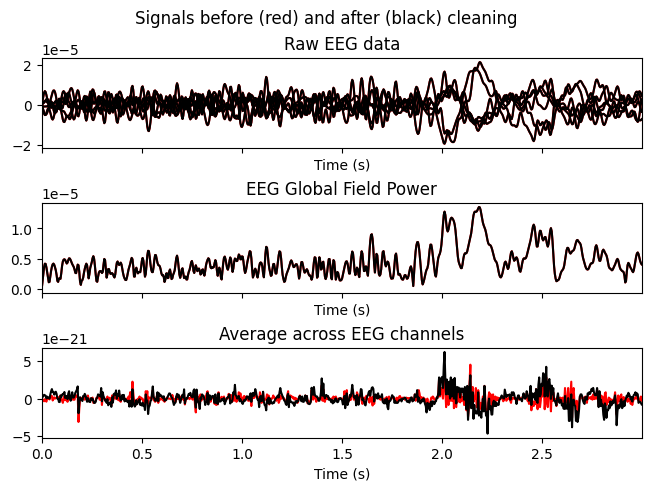

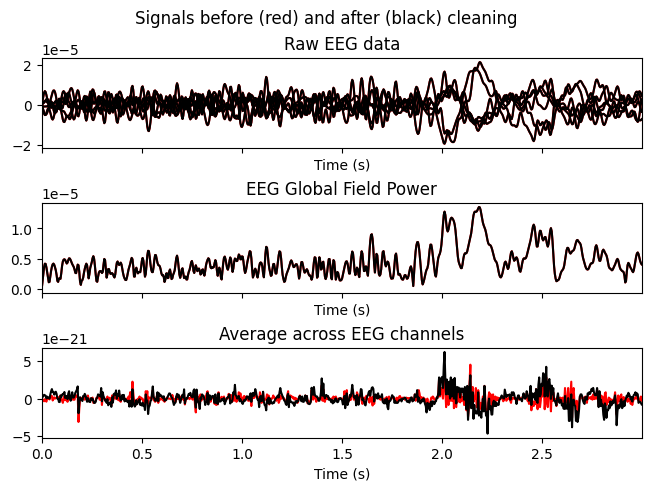

In [21]:
ica.plot_overlay(filt_raw)

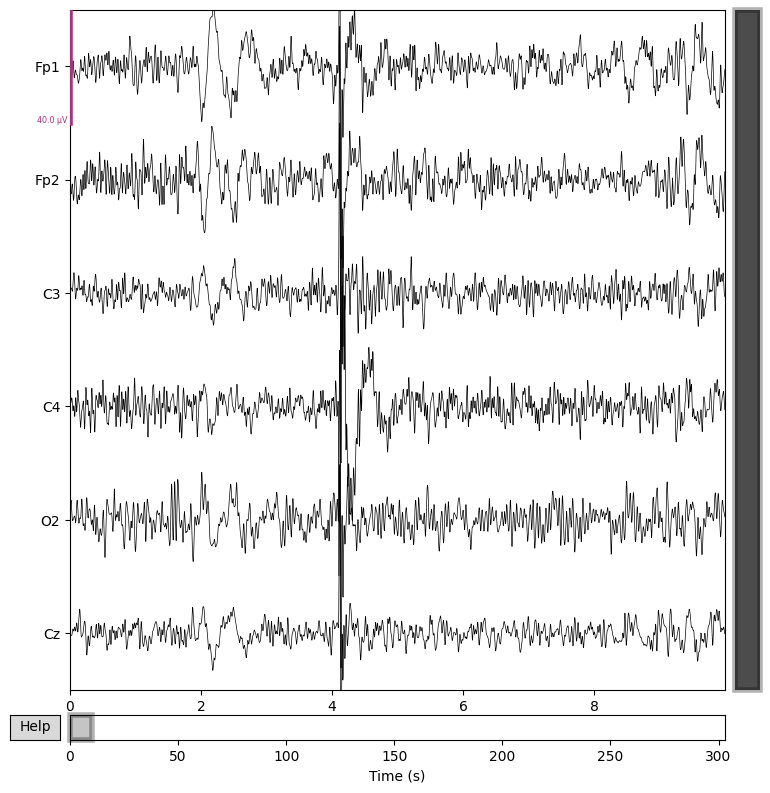

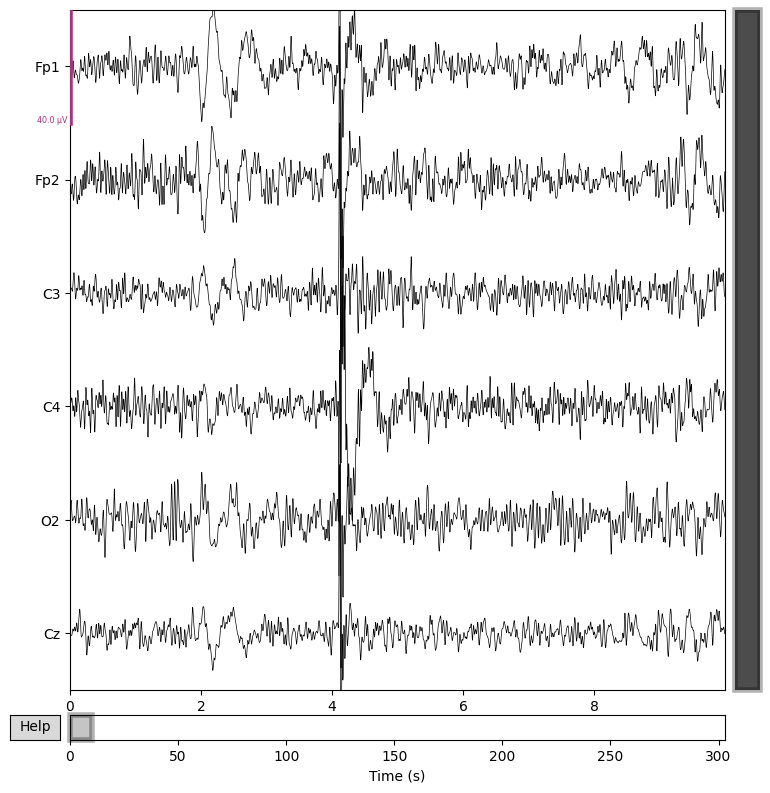

In [19]:
filt_raw.plot()

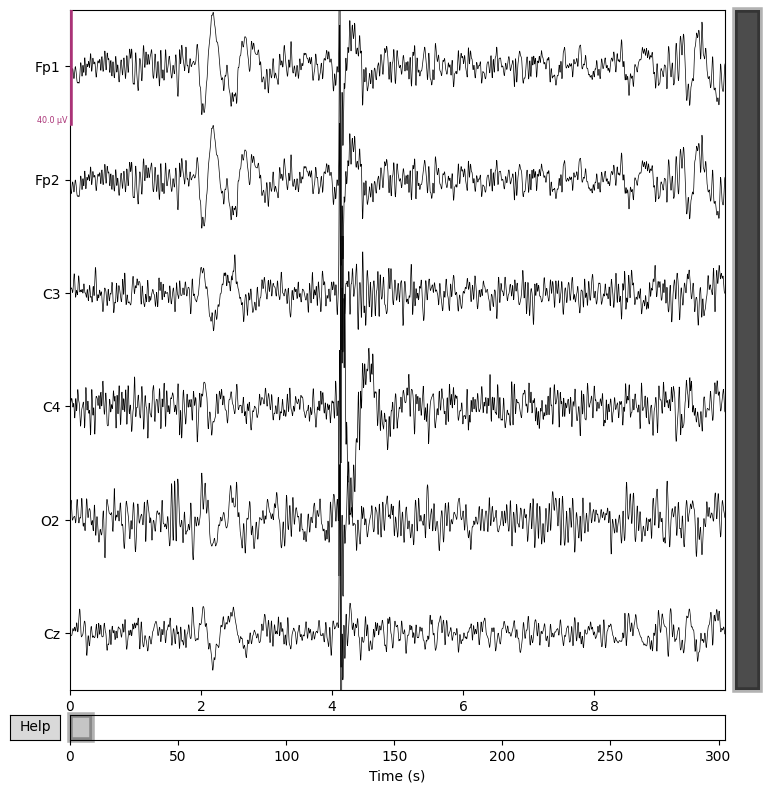

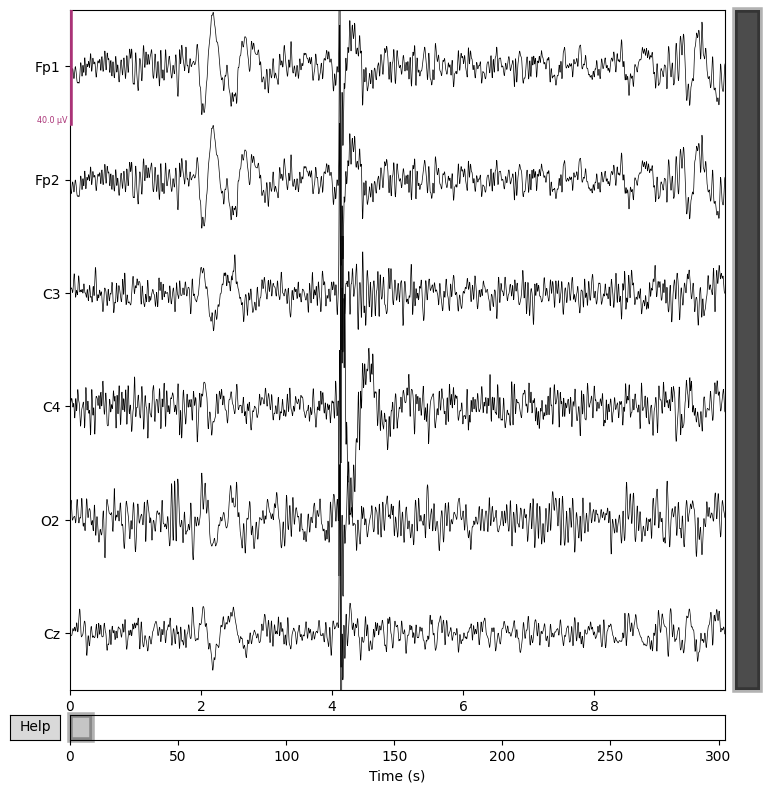

In [20]:
preprocessed.plot()

In [28]:
SEGMENT_LENGTH = 10
SFREQ = 1000 / 4
CHUNK_SAMPLES = int(SEGMENT_LENGTH * SFREQ)

df = preprocessed.to_data_frame()
df

,time,Fp1,Fp2,C3,C4,O2,Cz
0,0.000000,0.021768,0.020920,0.024269,-0.022201,-0.047920,0.003164
1,0.003906,-1.361814,-1.368493,0.586706,0.494326,2.123809,-0.474533
2,0.007812,-2.780180,-2.792508,1.112385,0.864373,4.348426,-0.752496
3,0.011719,-4.062679,-4.079898,1.524322,1.238974,6.190800,-0.811519
4,0.015625,-4.878949,-4.899495,1.776015,1.785213,6.995631,-0.778415
...,...,...,...,...,...,...,...
77563,302.980469,-0.509295,-0.531010,4.629638,0.996757,-9.265093,4.679004
77564,302.984375,-1.668174,-1.691613,4.275679,1.625323,-7.323013,4.781798
77565,302.988281,-1.962546,-1.982718,3.311376,1.630763,-4.786802,3.789927
77566,302.992188,-1.312469,-1.324556,1.819727,1.021085,-2.239010,2.035223


In [30]:
chunks = [df.iloc[i:i + CHUNK_SAMPLES] for i in range(0, len(df), CHUNK_SAMPLES)]
chunks

[          time       Fp1       Fp2        C3        C4        O2        Cz
 0     0.000000  0.021768  0.020920  0.024269 -0.022201 -0.047920  0.003164
 1     0.003906 -1.361814 -1.368493  0.586706  0.494326  2.123809 -0.474533
 2     0.007812 -2.780180 -2.792508  1.112385  0.864373  4.348426 -0.752496
 3     0.011719 -4.062679 -4.079898  1.524322  1.238974  6.190800 -0.811519
 4     0.015625 -4.878949 -4.899495  1.776015  1.785213  6.995631 -0.778415
 ...        ...       ...       ...       ...       ...       ...       ...
 2495  9.746094 -4.309444 -4.335625  4.047953 -1.137047  3.056985  2.677179
 2496  9.750000 -3.954737 -3.973041  2.331964 -1.294559  4.077253  2.813120
 2497  9.753906 -3.677059 -3.690703  1.351864 -1.374987  4.413818  2.977067
 2498  9.757812 -3.792571 -3.806825  1.351915 -0.963800  3.974094  3.237187
 2499  9.761719 -4.455498 -4.474908  1.994088  0.291975  2.991449  3.652894
 
 [2500 rows x 7 columns],
            time       Fp1       Fp2        C3        C4    

In [ ]:
# TODO each segment before sending into classifier -> Z-score
norm = zscore(raw) # TODO Make sure this is in the proper axis
norm

## CANE

In [ ]:
df = pd.read_csv(CANE_DIR / "anxiety" / "ec" / "0041_Ec.csv")
df = df.iloc[::2].reset_index(drop=True)
df

In [ ]:
# Extract EEG channels
eeg_channels = ['d1','d2','d3','d4','d5','d6','d7','d8']
data = df[eeg_channels].to_numpy()  # shape (n_channels, n_samples)
data

In [ ]:
norm = zscore(data)
norm

In [ ]:
norm = data - data.min(axis=0)
norm


In [ ]:
print(norm.min(axis=0))
print(norm.max(axis=0))


In [ ]:
# Sampling rate - TODO looks like every 4 millisecond I have two entries, wtf?
sfreq = 250.0  # replace with your actual sampling rate
# Create MNE info
info = mne.create_info(ch_names=eeg_channels, sfreq=sfreq, ch_types='eeg')

# Create Raw object
raw = mne.io.RawArray(norm.T, info)
print(raw.info)
raw.plot()

# (Optional) Apply filters, ICA, etc.
# raw.filter(0.5, 70)
# raw.notch_filter(50)
#
# # (Optional) Add timestamps as annotations
# raw.set_meas_date(None)  # if timestamps are relative, keep None



In [ ]:
df = pd.read_csv(CANE_DIR / "anxiety" / "ec" / "0041_Ec.csv" )
print(len(df))
df = df.iloc[::2].reset_index(drop=True)
print(len(df))
# Extract EEG channels

eeg_channels = ['d1','d2','d3','d4','d5','d6','d7','d8']
df = df[eeg_channels].to_numpy().T  # shape (n_channels, n_samples)

# Optionally normalize (since units look raw)
# data = zscore(data, axis=1)
sfreq = 250
# Build MNE Raw object
info = mne.create_info(ch_names=eeg_channels, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(df , info)

raw.plot()

## Filtering